# Banking Analytics — Credit Card Customer

**Dataset:** `CreditCardCustomer.csv` (10,127 ลูกค้า, 21 คอลัมน์)

| ส่วน | โจทย์ | ประเภทปัญหา |
|---|---|---|
| Case 1 | Customer Churn Prediction — ทำนายลูกค้าที่เสี่ยงยกเลิกบัตร | Binary Classification |
| Case 2 | Data-Driven Up-selling — หาลูกค้า Blue ที่โปรไฟล์คล้ายลูกค้าบัตรพรีเมียม (Lookalike) | Classification → Scoring |
| Case 3 | Predictive Credit Limit — ทำนายวงเงินที่เหมาะสมจากพฤติกรรมการใช้งาน | Regression |
| Part 2 | ตอบคำถาม TA จากผล EDA | Analysis |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             RocCurveDisplay, ConfusionMatrixDisplay,
                             mean_absolute_error, root_mean_squared_error, r2_score)

sns.set_theme(style="whitegrid", font="Sarabun")   # ฟอนต์ไทย (ถ้าเครื่องไม่มีให้เปลี่ยนเป็น "Thonburi")
plt.rcParams["font.family"] = ["Sarabun", "Thonburi"]
plt.rcParams["axes.unicode_minus"] = False          # กันเครื่องหมายลบเพี้ยนเมื่อเปลี่ยนฟอนต์
plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42

In [2]:
df = pd.read_csv("CreditCardCustomer.csv")
print(df.shape)
df.head()

(10127, 21)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


## 0. Exploratory Data Analysis (EDA)

เริ่มจากตรวจสอบโครงสร้างข้อมูล ค่า missing และการกระจายของตัวแปรเป้าหมายแต่ละเคส

In [3]:
df.info()
print("\nMissing values รวม:", df.isna().sum().sum())
print("\nค่า 'Unknown' ในคอลัมน์ categorical:")
for c in ["Education_Level", "Marital_Status", "Income_Category"]:
    print(f"  {c}: {(df[c] == 'Unknown').sum()} แถว")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

> ไม่มี missing value แบบ NaN แต่มีค่า **"Unknown"** ในคอลัมน์ Education_Level / Marital_Status / Income_Category ซึ่งเราจะเก็บไว้เป็นหมวดหมู่หนึ่ง (ไม่ทิ้งแถว เพราะจะเสียข้อมูลกว่า 1,500 แถว)

In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,7.391776e+08,36903783.45,708082083.0,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
Customer_Age,10127.0,4.633000e+01,8.02,26.0,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
Dependent_count,10127.0,2.350000e+00,1.30,0.0,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
Months_on_book,10127.0,3.593000e+01,7.99,13.0,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
Total_Relationship_Count,10127.0,3.810000e+00,1.55,1.0,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Months_Inactive_12_mon,10127.0,2.340000e+00,1.01,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Contacts_Count_12_mon,10127.0,2.460000e+00,1.11,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Credit_Limit,10127.0,8.631950e+03,9088.78,1438.3,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
Total_Revolving_Bal,10127.0,1.162810e+03,814.99,0.0,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03
Avg_Open_To_Buy,10127.0,7.469140e+03,9090.69,3.0,1.324500e+03,3.474000e+03,9.859000e+03,3.451600e+04


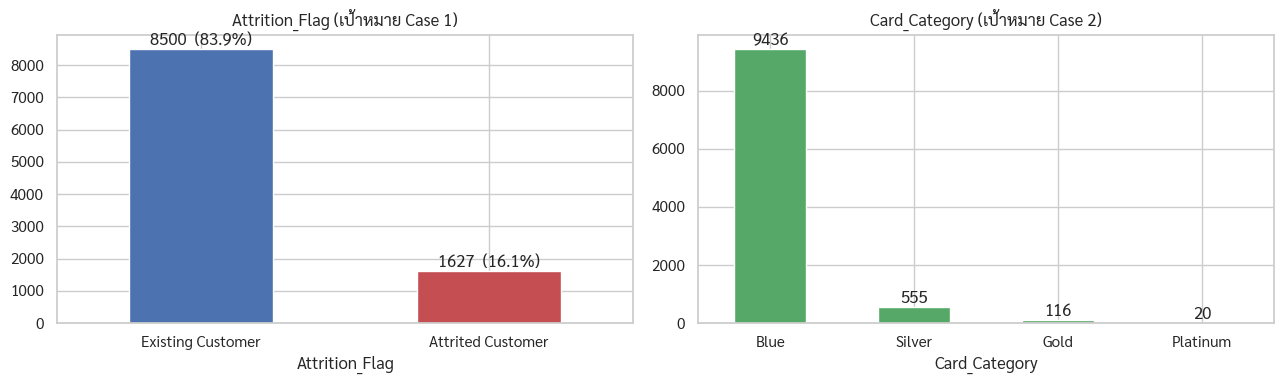

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["Attrition_Flag"].value_counts().plot.bar(ax=axes[0], color=["#4C72B0", "#C44E52"], rot=0)
axes[0].set_title("Attrition_Flag (เป้าหมาย Case 1)")
for i, v in enumerate(df["Attrition_Flag"].value_counts()):
    axes[0].text(i, v, f"{v}  ({v/len(df):.1%})", ha="center", va="bottom")

df["Card_Category"].value_counts().plot.bar(ax=axes[1], color="#55A868", rot=0)
axes[1].set_title("Card_Category (เป้าหมาย Case 2)")
for i, v in enumerate(df["Card_Category"].value_counts()):
    axes[1].text(i, v, f"{v}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

**ข้อสังเกตสำคัญ:**
- Churn (Attrited Customer) มีเพียง **~16%** → ข้อมูล **imbalanced** ต้องระวังตอนเทรนโมเดล Case 1
- บัตร Blue ครองสัดส่วน **~93%** → กลุ่มพรีเมียม (Silver+Gold+Platinum) มีแค่ ~7% ซึ่งเป็นโจทย์ของ Case 2

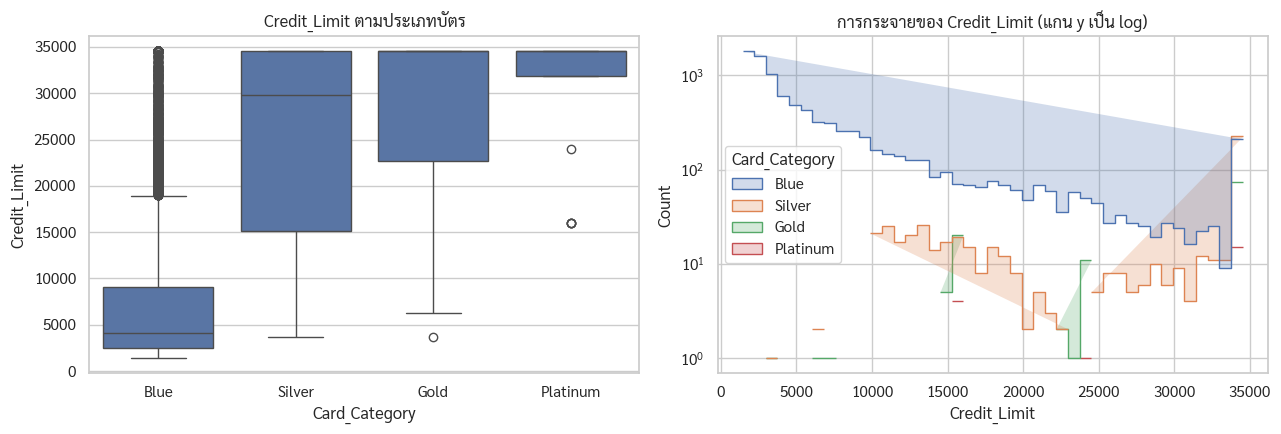

,count,mean,std,min,25%,50%,75%,max
Card_Category,,,,,,,,
Blue,9436.0,7364.0,7644.0,1438.0,2476.0,4105.0,9070.0,34516.0
Silver,555.0,25278.0,9653.0,3735.0,15153.0,29808.0,34516.0,34516.0
Gold,116.0,28416.0,8674.0,3735.0,22724.0,34516.0,34516.0,34516.0
Platinum,20.0,30283.0,7698.0,15987.0,31882.0,34516.0,34516.0,34516.0


In [6]:
# Credit_Limit แยกตาม Card_Category — หลักฐานสำคัญสำหรับคำถาม TA ข้อ 1
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
order = ["Blue", "Silver", "Gold", "Platinum"]

sns.boxplot(data=df, x="Card_Category", y="Credit_Limit", order=order, ax=axes[0])
axes[0].set_title("Credit_Limit ตามประเภทบัตร")

sns.histplot(data=df, x="Credit_Limit", hue="Card_Category", hue_order=order,
             element="step", log_scale=(False, True), ax=axes[1])
axes[1].set_title("การกระจายของ Credit_Limit (แกน y เป็น log)")
plt.tight_layout()
plt.show()

df.groupby("Card_Category")["Credit_Limit"].describe().round(0).loc[order]

**เห็นความผิดปกติชัดเจน:** ลูกค้าบัตร Blue บางคนมีวงเงินสูงถึง 34,516 ซึ่ง**เท่ากับค่า max ของ Platinum** และค่า max 34,516 ปรากฏเป็นเพดาน (cap) ของทุกประเภทบัตร → ประเภทบัตรกับวงเงิน**ไม่ได้สัมพันธ์กันแบบลำดับขั้นอย่างที่ตรรกะธุรกิจคาดหวัง** (เก็บประเด็นนี้ไว้ตอบ Part 2 ข้อ 1)

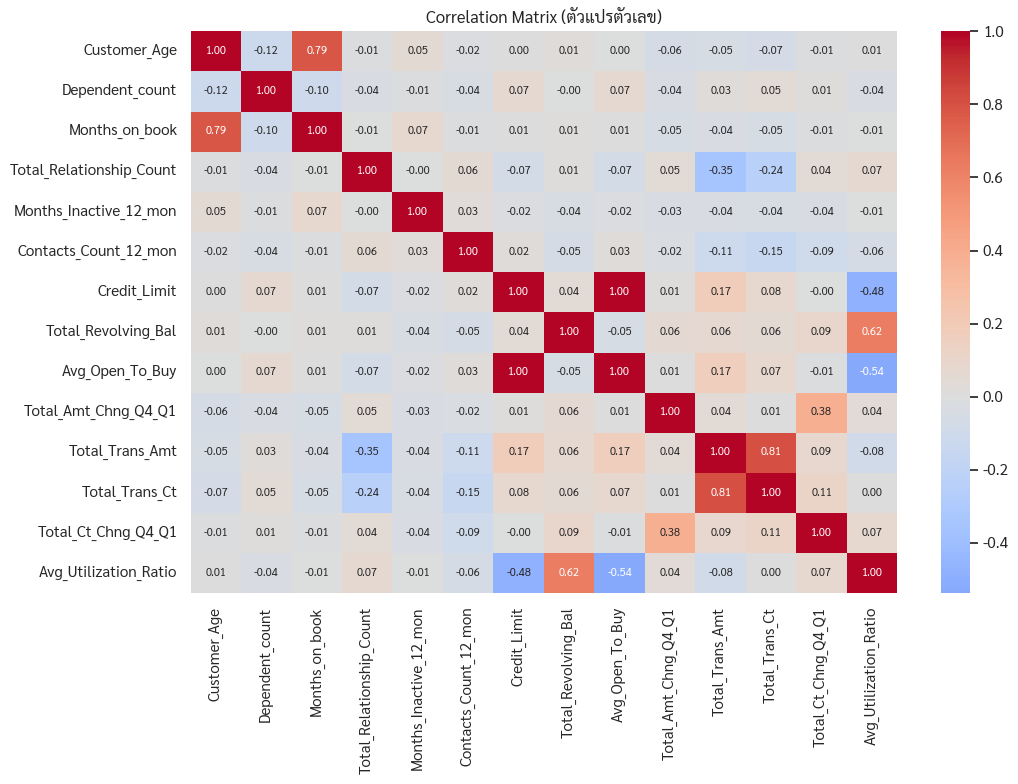

In [7]:
# Correlation ระหว่างตัวแปรตัวเลข
num_cols = df.select_dtypes(include=np.number).columns.drop("CLIENTNUM")
plt.figure(figsize=(11, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 8})
plt.title("Correlation Matrix (ตัวแปรตัวเลข)")
plt.tight_layout()
plt.show()

**Leakage ที่ต้องระวัง (สำคัญมากสำหรับ Case 3):**
- `Avg_Open_To_Buy` ≈ `Credit_Limit − Total_Revolving_Bal` → correlation ≈ 1.00 กับ Credit_Limit
- `Avg_Utilization_Ratio` = `Total_Revolving_Bal / Credit_Limit` → คำนวณจาก Credit_Limit โดยตรง

ถ้าใช้ทำนาย Credit_Limit จะเป็นการ "แอบดูเฉลย" (data leakage) ต้องตัดออก

/var/folders/g5/b8xw3klx44dby851pn068kr00000gn/T/ipykernel_37658/3118378918.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Attrition_Flag", y=col, ax=ax,
/var/folders/g5/b8xw3klx44dby851pn068kr00000gn/T/ipykernel_37658/3118378918.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Existing", "Attrited"])
/var/folders/g5/b8xw3klx44dby851pn068kr00000gn/T/ipykernel_37658/3118378918.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Attrition_Flag", y=col, ax=ax,
/var/folders/g5/b8xw3klx44dby851pn068kr00000gn/T/ipykernel_37658/3118378918.py:9: UserWarning: set_

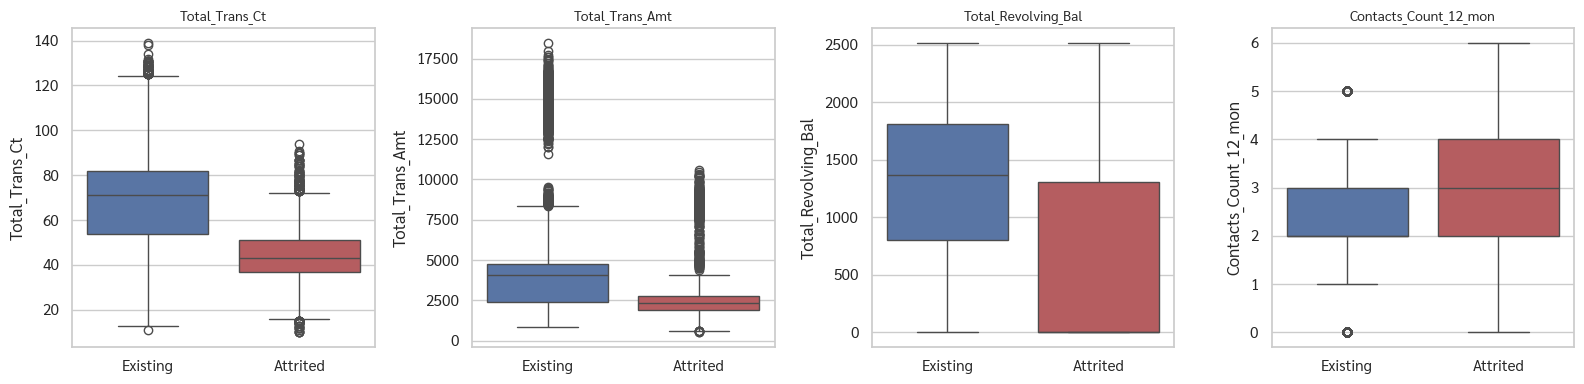

In [8]:
# พฤติกรรมของลูกค้าที่ churn ต่างจากลูกค้าปัจจุบันอย่างไร
behav = ["Total_Trans_Ct", "Total_Trans_Amt", "Total_Revolving_Bal", "Contacts_Count_12_mon"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, behav):
    sns.boxplot(data=df, x="Attrition_Flag", y=col, ax=ax,
                palette={"Existing Customer": "#4C72B0", "Attrited Customer": "#C44E52"})
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.set_xticklabels(["Existing", "Attrited"])
plt.tight_layout()
plt.show()

**Insight:** ลูกค้าที่ยกเลิกบัตร (Attrited) มีจำนวนธุรกรรม ยอดใช้จ่าย และยอดคงค้างต่ำกว่าชัดเจน แต่ติดต่อธนาคารบ่อยกว่า → ฟีเจอร์พฤติกรรมเหล่านี้น่าจะเป็นตัวทำนายหลักของโมเดล Case 1

---
## Part 1 — Case 1: Customer Churn Prediction

**แนวทาง:**
1. Target: `Attrition_Flag` → Attrited = 1, Existing = 0
2. ตัด `CLIENTNUM` (เป็นแค่ ID) และ one-hot encode ตัวแปร categorical
3. แบ่ง train/test แบบ **stratified** 80/20 เพื่อรักษาสัดส่วน churn
4. เทียบ 2 โมเดล: **Logistic Regression** (baseline) กับ **Random Forest** โดยใส่ `class_weight="balanced"` ทั้งคู่เพื่อรับมือ class imbalance
5. เน้นดู **Recall ของคลาส Attrited** เพราะเชิงธุรกิจ การ "จับลูกค้าที่จะหนีไม่ได้" (False Negative) แพงกว่าการส่งโปรโมชันเกิน (False Positive)

In [9]:
# เตรียมข้อมูล Case 1
X_raw = df.drop(columns=["CLIENTNUM", "Attrition_Flag"])
y = (df["Attrition_Flag"] == "Attrited Customer").astype(int)

X = pd.get_dummies(X_raw, drop_first=True)
print("จำนวนฟีเจอร์หลัง one-hot encode:", X.shape[1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]} แถว | Test: {X_test.shape[0]} แถว | churn ใน train: {y_train.mean():.1%}")

จำนวนฟีเจอร์หลัง one-hot encode: 32
Train: 8101 แถว | Test: 2026 แถว | churn ใน train: 16.1%


In [10]:
# Baseline: Logistic Regression (ต้อง scale ก่อน)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
logreg.fit(X_train_sc, y_train)
pred_lr = logreg.predict(X_test_sc)
proba_lr = logreg.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression (baseline) ===")
print(classification_report(y_test, pred_lr, target_names=["Existing", "Attrited"]))
print(f"ROC-AUC: {roc_auc_score(y_test, proba_lr):.4f}")

/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/lib/python3.10/site-packages/sklearn/l

=== Logistic Regression (baseline) ===
              precision    recall  f1-score   support

    Existing       0.96      0.86      0.91      1701
    Attrited       0.53      0.82      0.64       325

    accuracy                           0.85      2026
   macro avg       0.75      0.84      0.78      2026
weighted avg       0.89      0.85      0.87      2026

ROC-AUC: 0.9207


In [11]:
# โมเดลหลัก: Random Forest
rf_churn = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                  random_state=RANDOM_STATE, n_jobs=-1)
rf_churn.fit(X_train, y_train)
pred_rf = rf_churn.predict(X_test)
proba_rf = rf_churn.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, pred_rf, target_names=["Existing", "Attrited"]))
print(f"ROC-AUC: {roc_auc_score(y_test, proba_rf):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

    Existing       0.95      0.99      0.97      1701
    Attrited       0.93      0.74      0.82       325

    accuracy                           0.95      2026
   macro avg       0.94      0.86      0.90      2026
weighted avg       0.95      0.95      0.95      2026

ROC-AUC: 0.9845


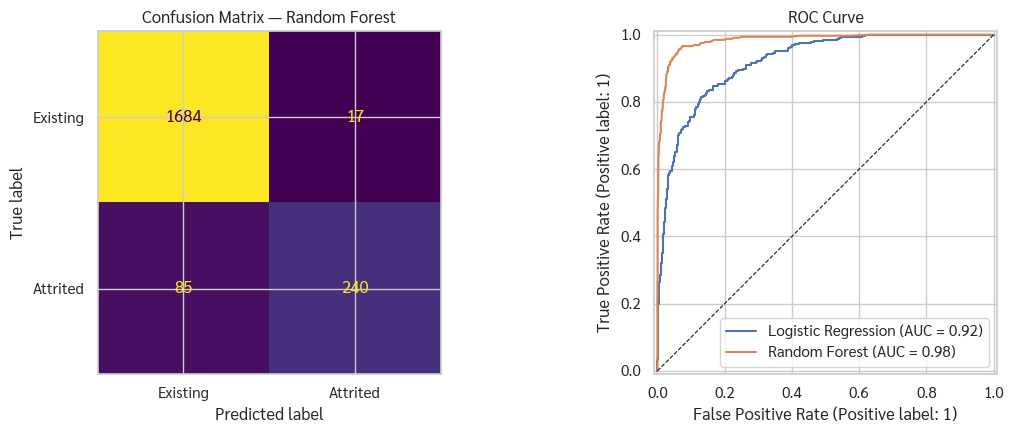

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_rf),
                       display_labels=["Existing", "Attrited"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix — Random Forest")

RocCurveDisplay.from_predictions(y_test, proba_lr, name="Logistic Regression", ax=axes[1])
RocCurveDisplay.from_predictions(y_test, proba_rf, name="Random Forest", ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[1].set_title("ROC Curve")
plt.tight_layout()
plt.show()

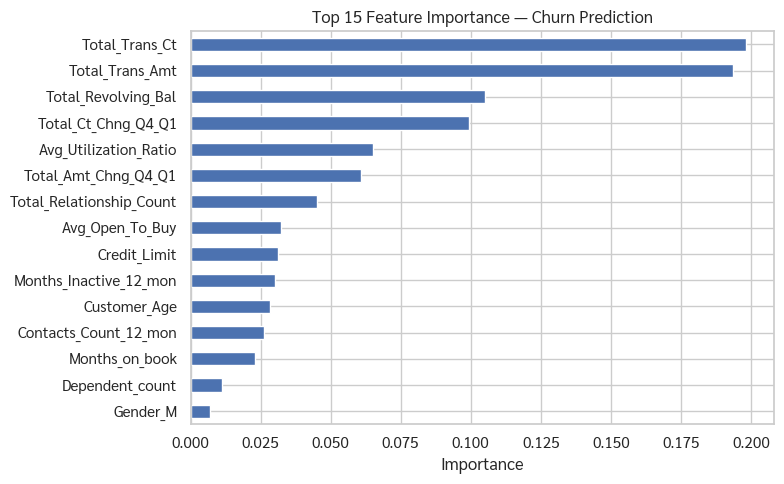

In [13]:
# ฟีเจอร์ไหนสำคัญที่สุดในการทำนาย churn
imp = pd.Series(rf_churn.feature_importances_, index=X.columns).nlargest(15)
imp.sort_values().plot.barh(figsize=(8, 5), color="#4C72B0")
plt.title("Top 15 Feature Importance — Churn Prediction")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**สรุป Case 1:** Random Forest ทำได้ดีกว่า baseline ชัดเจน ฟีเจอร์ที่สำคัญที่สุดล้วนเป็น**พฤติกรรมการใช้บัตร** (Total_Trans_Ct, Total_Trans_Amt, Total_Revolving_Bal, Total_Ct_Chng_Q4_Q1) ไม่ใช่ข้อมูล demographic → ธนาคารสามารถใช้คะแนนความน่าจะเป็นจากโมเดลนี้จัดลำดับลูกค้าเข้า Retention Program ได้ 

---
## Part 1 — Case 2: Data-Driven Up-selling (Lookalike Model)

**แนวทาง:**
1. สร้าง label ใหม่: Premium (Silver/Gold/Platinum) = 1, Blue = 0
2. **ตัด `Credit_Limit` และ `Avg_Open_To_Buy` ออกจากฟีเจอร์** — เพราะวงเงินถูกกำหนดตามประเภทบัตรอยู่แล้ว เราต้องการหา lookalike จาก**โปรไฟล์และพฤติกรรมการใช้จ่าย**จริง ๆ
3. เทรน Random Forest แยก Premium vs Blue แล้วประเมินด้วย ROC-AUC
4. ให้คะแนน **ลูกค้า Blue ทุกคน** ด้วยวิธี **out-of-fold (5-fold CV)** — ถ้าให้โมเดลที่เทรนแล้วให้คะแนนข้อมูลเทรนของตัวเอง Random Forest จะ "จำ" ข้อมูลและกดคะแนน Blue ต่ำผิดจริง ดังนั้นแต่ละคนต้องถูกให้คะแนนโดยโมเดลที่**ไม่เคยเห็นเขาตอนเทรน**
5. ความน่าจะเป็นที่ได้ = **Lookalike Score** → จัดอันดับแล้วเลือก top-N ตามงบแคมเปญ

In [14]:
# เตรียมข้อมูล Case 2
premium = {"Silver", "Gold", "Platinum"}
df["Is_Premium"] = df["Card_Category"].isin(premium).astype(int)
print(df["Is_Premium"].value_counts().rename({0: "Blue", 1: "Premium"}))

leak_cols = ["CLIENTNUM", "Card_Category", "Is_Premium", "Credit_Limit", "Avg_Open_To_Buy"]
X2_raw = df.drop(columns=leak_cols)
X2 = pd.get_dummies(X2_raw, drop_first=True)
y2 = df["Is_Premium"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=RANDOM_STATE)

Is_Premium
Blue       9436
Premium     691
Name: count, dtype: int64


In [15]:
rf_up = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                               random_state=RANDOM_STATE, n_jobs=-1)
rf_up.fit(X2_train, y2_train)
proba_up = rf_up.predict_proba(X2_test)[:, 1]

print("=== Premium vs Blue Classifier ===")
print(classification_report(y2_test, rf_up.predict(X2_test), target_names=["Blue", "Premium"]))
print(f"ROC-AUC: {roc_auc_score(y2_test, proba_up):.4f}")

=== Premium vs Blue Classifier ===
              precision    recall  f1-score   support

        Blue       0.94      1.00      0.97      1888
     Premium       0.82      0.10      0.18       138

    accuracy                           0.94      2026
   macro avg       0.88      0.55      0.57      2026
weighted avg       0.93      0.94      0.91      2026

ROC-AUC: 0.9267


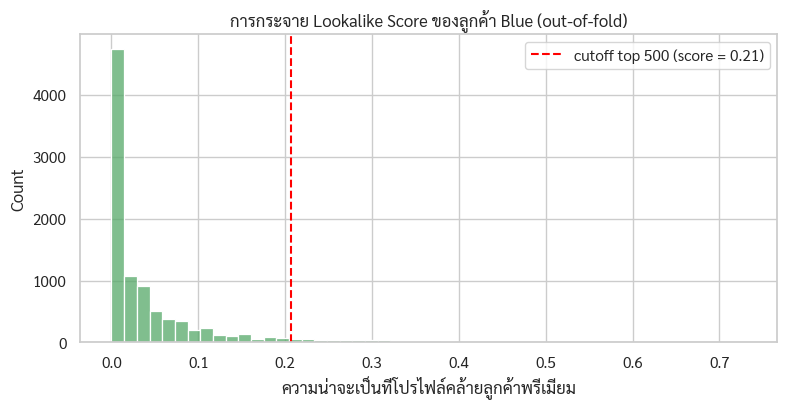

เลือกกลุ่มเป้าหมายแคมเปญ top 500 คน จากลูกค้า Blue ทั้งหมด 9,436 คน

Top 10 ลูกค้าเป้าหมายส่งแคมเปญอัปเกรดบัตร:


,CLIENTNUM,Customer_Age,Income_Category,Total_Trans_Amt,Total_Trans_Ct,Credit_Limit,Lookalike_Score
9383,712952283,50,$120K +,14474,121,34516.0,0.730000
9845,719430483,51,$120K +,14145,119,34516.0,0.656667
8962,794191008,46,$120K +,7552,87,34516.0,0.633333
9460,714403983,43,$80K - $120K,13545,112,34427.0,0.620000
9730,720356133,48,Unknown,14812,101,23939.0,0.606667
9424,712180308,36,$120K +,14755,123,27929.0,0.573333
9024,709619433,52,$120K +,8604,108,34516.0,0.556667
9969,758802333,40,$120K +,14641,117,20891.0,0.553333
8977,712839633,38,$80K - $120K,8871,97,34516.0,0.550000
9330,716323683,31,$80K - $120K,13177,106,32791.0,0.546667


In [16]:
# ให้คะแนน Lookalike กับลูกค้า Blue ทุกคนแบบ out-of-fold
from sklearn.model_selection import cross_val_predict, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_scores = cross_val_predict(rf_up, X2, y2, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

blue_mask = df["Card_Category"] == "Blue"
blue_scores = oof_scores[blue_mask.values]

lookalike = df.loc[blue_mask, ["CLIENTNUM", "Customer_Age", "Income_Category",
                               "Total_Trans_Amt", "Total_Trans_Ct", "Credit_Limit"]].copy()
lookalike["Lookalike_Score"] = blue_scores
lookalike = lookalike.sort_values("Lookalike_Score", ascending=False)

TOP_N = 500  # ขนาดกลุ่มเป้าหมายตามงบแคมเปญ
cutoff = lookalike["Lookalike_Score"].iloc[TOP_N - 1]

plt.figure(figsize=(9, 4))
sns.histplot(blue_scores, bins=50, color="#55A868")
plt.axvline(cutoff, color="red", ls="--", label=f"cutoff top {TOP_N} (score = {cutoff:.2f})")
plt.title("การกระจาย Lookalike Score ของลูกค้า Blue (out-of-fold)")
plt.xlabel("ความน่าจะเป็นที่โปรไฟล์คล้ายลูกค้าพรีเมียม")
plt.legend()
plt.show()

print(f"เลือกกลุ่มเป้าหมายแคมเปญ top {TOP_N} คน จากลูกค้า Blue ทั้งหมด {blue_mask.sum():,} คน")
print("\nTop 10 ลูกค้าเป้าหมายส่งแคมเปญอัปเกรดบัตร:")
lookalike.head(10)

**สรุป Case 2:** โมเดลแยกโปรไฟล์ Premium/Blue ได้ ROC-AUC ~0.93 และให้ **Lookalike Score** (แบบ out-of-fold เพื่อไม่ให้คะแนนเอนเอียง) กับลูกค้า Blue ทุกคน ทีมการตลาดสามารถเลือก top-N ตามงบแคมเปญ (ในที่นี้สาธิต top 500) แทนการหว่านแคมเปญทั้งฐาน 9,436 คน — สังเกตว่าลูกค้ากลุ่ม top มียอดใช้จ่าย/จำนวนธุรกรรมสูงกว่าค่าเฉลี่ยของ Blue ชัดเจน ตรงตามคอนเซปต์ lookalike

---
## Part 1 — Case 3: Predictive Credit Limit

**แนวทาง:**
1. Target: `Credit_Limit` (ปัญหา regression)
2. **ตัดฟีเจอร์ leakage:** `Avg_Open_To_Buy` (= Credit_Limit − Revolving_Bal) และ `Avg_Utilization_Ratio` (= Revolving_Bal ÷ Credit_Limit) — สองตัวนี้คำนวณมาจากคำตอบโดยตรง
3. ตัด `Card_Category` ด้วย เพราะประเภทบัตรถูกกำหนดจากวงเงิน (วนเป็นงูกินหาง) — โจทย์ต้องการทำนายจาก**พฤติกรรมการใช้งานจริงและยอดคงค้าง**
4. Credit_Limit มีการกระจายเบ้ขวาแรง → ใช้ **log-transform** target ตอนเทรน แล้วแปลงกลับตอนวัดผล
5. วัดด้วย MAE / RMSE / R²

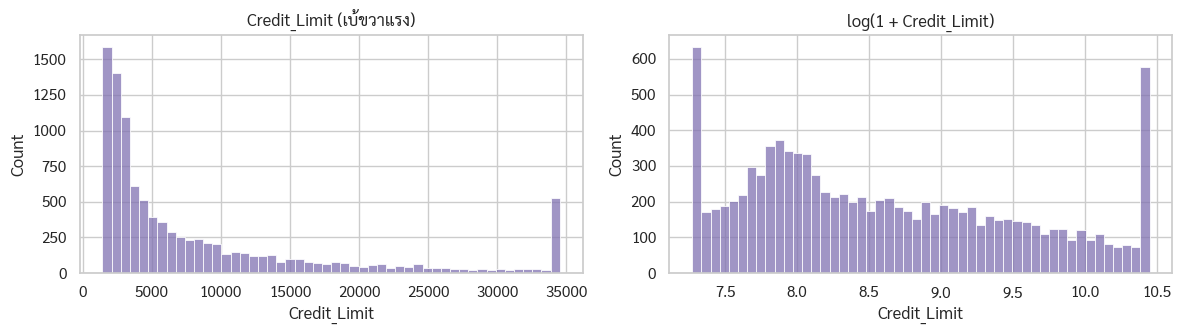

In [17]:
# การกระจายของ target
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
sns.histplot(df["Credit_Limit"], bins=50, ax=axes[0], color="#8172B2")
axes[0].set_title("Credit_Limit (เบ้ขวาแรง)")
sns.histplot(np.log1p(df["Credit_Limit"]), bins=50, ax=axes[1], color="#8172B2")
axes[1].set_title("log(1 + Credit_Limit)")
plt.tight_layout()
plt.show()

In [18]:
# เตรียมข้อมูล Case 3
drop3 = ["CLIENTNUM", "Is_Premium", "Credit_Limit",
         "Avg_Open_To_Buy", "Avg_Utilization_Ratio", "Card_Category"]
X3 = pd.get_dummies(df.drop(columns=drop3), drop_first=True)
y3 = df["Credit_Limit"]
y3_log = np.log1p(y3)

X3_train, X3_test, y3_train_log, y3_test_log = train_test_split(
    X3, y3_log, test_size=0.2, random_state=RANDOM_STATE)

rf_limit = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_limit.fit(X3_train, y3_train_log)

pred_log = rf_limit.predict(X3_test)
pred_limit = np.expm1(pred_log)          # แปลงกลับเป็นบาทจริง
actual_limit = np.expm1(y3_test_log)

print(f"MAE : {mean_absolute_error(actual_limit, pred_limit):,.0f}")
print(f"RMSE: {root_mean_squared_error(actual_limit, pred_limit):,.0f}")
print(f"R²  : {r2_score(actual_limit, pred_limit):.4f}")

MAE : 4,712
RMSE: 7,519
R²  : 0.3171


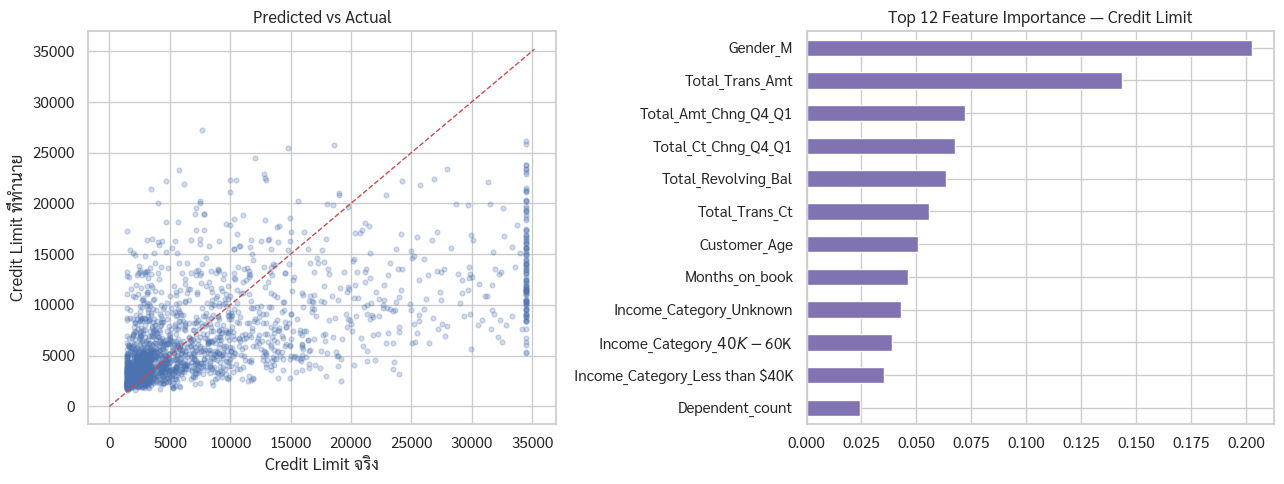

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(actual_limit, pred_limit, alpha=0.25, s=12, color="#4C72B0")
lims = [0, actual_limit.max() * 1.02]
axes[0].plot(lims, lims, "r--", lw=1)
axes[0].set_xlabel("Credit Limit จริง")
axes[0].set_ylabel("Credit Limit ที่ทำนาย")
axes[0].set_title("Predicted vs Actual")

imp3 = pd.Series(rf_limit.feature_importances_, index=X3.columns).nlargest(12)
imp3.sort_values().plot.barh(ax=axes[1], color="#8172B2")
axes[1].set_title("Top 12 Feature Importance — Credit Limit")
plt.tight_layout()
plt.show()

**สรุป Case 3:** โมเดลทำนายวงเงินจากพฤติกรรมล้วน ๆ ได้ระดับหนึ่ง ฟีเจอร์เด่นคือรายได้ (Income_Category) เพศ และพฤติกรรมใช้จ่าย ค่า R² ไม่สูงมากซึ่ง**สมเหตุสมผล** เพราะวงเงินจริงในข้อมูลถูกกำหนดโดยนโยบายธนาคาร (มีเพดาน 34,516 ชัดเจน) ไม่ใช่จากพฤติกรรมล้วน ๆ — ในการใช้งานจริงควรใช้ผลทำนายเป็น "วงเงินแนะนำ" ประกอบการพิจารณาของเจ้าหน้าที่สินเชื่อ เพื่อลดโอกาสให้วงเงินสูงเกินความสามารถชำระ (NPL)

---
## Part 2: ตอบคำถามพี่ TA

### ข้อ 1 — ความขัดแย้งระหว่าง `Credit_Limit` และ `Card_Category`

In [20]:
# หลักฐานเชิงตัวเลขของความขัดแย้ง
stats = df.groupby("Card_Category")["Credit_Limit"].agg(["count", "median", "max"]).loc[order]
print(stats.round(0))

silver_med = df.loc[df["Card_Category"] == "Silver", "Credit_Limit"].median()
blue = df[df["Card_Category"] == "Blue"]
n_blue_over = (blue["Credit_Limit"] >= silver_med).sum()
print(f"\nลูกค้า Blue ที่วงเงิน >= ค่ากลางของ Silver ({silver_med:,.0f}): "
      f"{n_blue_over} คน ({n_blue_over/len(blue):.1%} ของ Blue ทั้งหมด)")
print(f"ลูกค้า Blue ที่วงเงินชนเพดาน 34,516 เท่า Platinum: "
      f"{(blue['Credit_Limit'] == 34516).sum()} คน")

               count   median      max
Card_Category                         
Blue            9436   4105.0  34516.0
Silver           555  29808.0  34516.0
Gold             116  34516.0  34516.0
Platinum          20  34516.0  34516.0

ลูกค้า Blue ที่วงเงิน >= ค่ากลางของ Silver (29,808): 313 คน (3.3% ของ Blue ทั้งหมด)
ลูกค้า Blue ที่วงเงินชนเพดาน 34,516 เท่า Platinum: 198 คน


**คำตอบข้อ 1**

**ความขัดแย้งที่พบ:**
1. **การกระจายทับซ้อนกันอย่างหนัก** — ตามตรรกะธุรกิจ บัตรระดับสูงกว่าควรมีวงเงินสูงกว่าเสมอ แต่ข้อมูลจริงพบลูกค้า Blue หลายร้อยคนที่วงเงินสูงกว่าค่ากลางของ Silver และมีลูกค้า Blue จำนวนหนึ่งที่วงเงิน**ชนเพดาน 34,516 เท่ากับ Platinum**
2. **ค่า max 34,516 เป็นเพดานเทียมของทุกประเภทบัตร** — บ่งชี้ว่าข้อมูลถูก cap ไว้ ไม่ใช่วงเงินจริงตามธรรมชาติ
3. **ขนาดกลุ่มต่างกันสุดขั้ว** — Blue 9,436 คน แต่ Platinum แค่ 20 คน สถิติของกลุ่มเล็กจึงไม่น่าเชื่อถือ

**ผลเสียถ้าใช้ร่วมกันโดยไม่ปรับแต่ง:**
- **Multicollinearity / ข้อมูลซ้ำซ้อน** — สองฟีเจอร์เล่าเรื่องเดียวกันแบบครึ่ง ๆ กลาง ๆ โมเดลเชิงเส้นจะตีความค่าสัมประสิทธิ์ผิดเพี้ยน
- **Data leakage ใน Case 2/3** — ถ้าใช้ Credit_Limit ทำนายประเภทบัตร (หรือกลับกัน) โมเดลจะได้คะแนนสูงเกินจริงจากความสัมพันธ์เชิงนโยบาย ไม่ใช่จากพฤติกรรมลูกค้า พอใช้งานจริงกับลูกค้าที่วงเงินยังไม่ถูกกำหนด โมเดลจะพัง
- **ตรรกะธุรกิจผิด** — โมเดลอาจเรียนรู้ว่า "Blue วงเงินสูง = ควรเป็นพรีเมียม" ทั้งที่จริงลูกค้ากลุ่มนี้อาจแค่ได้วงเงินสูงจากรายได้ แต่ไม่มีพฤติกรรมใช้จ่ายแบบลูกค้าพรีเมียมเลย → แคมเปญยิงพลาดเป้า

**วิธีปรับ:** เลือกใช้ตัวใดตัวหนึ่งตามโจทย์ (เราตัด Credit_Limit ออกใน Case 2 และตัด Card_Category ออกใน Case 3) หรือสร้างฟีเจอร์ใหม่ที่สะอาดกว่า เช่น ratio ของพฤติกรรมใช้จ่ายต่อวงเงิน

### ข้อ 2 — ใช้โมเดลกับ "ลูกค้าใหม่ที่ยังไม่เคยรูดบัตร" ได้หรือไม่?

ทดลองให้เห็นจริง: เทรนโมเดล churn ใหม่โดยใช้**เฉพาะฟีเจอร์ที่รู้ ณ วันสมัครบัตร** (demographic) แล้วเทียบกับโมเดลเต็ม

In [21]:
# ฟีเจอร์ที่รู้ตั้งแต่วันสมัคร (ไม่มีประวัติการใช้บัตร)
demo_cols = ["Customer_Age", "Gender", "Dependent_count",
             "Education_Level", "Marital_Status", "Income_Category"]
X_demo = pd.get_dummies(df[demo_cols], drop_first=True)

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_demo, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

rf_demo = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                 random_state=RANDOM_STATE, n_jobs=-1)
rf_demo.fit(Xd_train, yd_train)
auc_demo = roc_auc_score(yd_test, rf_demo.predict_proba(Xd_test)[:, 1])
auc_full = roc_auc_score(y_test, proba_rf)

print(f"ROC-AUC โมเดลเต็ม (มีฟีเจอร์พฤติกรรม): {auc_full:.4f}")
print(f"ROC-AUC โมเดล demographic อย่างเดียว : {auc_demo:.4f}  (0.5 = เดาสุ่ม)")

ROC-AUC โมเดลเต็ม (มีฟีเจอร์พฤติกรรม): 0.9845
ROC-AUC โมเดล demographic อย่างเดียว : 0.5031  (0.5 = เดาสุ่ม)


**คำตอบข้อ 2**

**โมเดลใน Part 1 ใช้กับลูกค้าใหม่ไม่ได้** ด้วยเหตุผล 2 ระดับ:
1. **เชิงเทคนิค** — ฟีเจอร์หลักของโมเดล (Total_Trans_Ct, Total_Trans_Amt, Total_Revolving_Bal, Months_Inactive_12_mon ฯลฯ) ล้วนต้องมีประวัติใช้บัตรย้อนหลัง 12 เดือน ลูกค้าใหม่จะมีค่าเป็น 0/ว่างทั้งหมด โมเดลยังคำนวณได้แต่ผลลัพธ์ไร้ความหมาย (garbage in, garbage out) — นี่คือปัญหา **Cold-Start**
2. **เชิงพิสูจน์** — จากการทดลองข้างบน พอเหลือแค่ demographic ค่า ROC-AUC ร่วงจาก ~0.99 เหลือใกล้ 0.5–0.6 แปลว่าข้อมูล ณ วันสมัครแทบทำนาย churn ไม่ได้เลย

**กลยุทธ์ปรับ Feature Selection ให้ตอบโจทย์เชิงปฏิบัติ:**
1. **แยกโมเดลตามช่วงอายุลูกค้า (Two-Stage Model)**
   - *ลูกค้าใหม่ (0–3 เดือน):* ใช้เฉพาะฟีเจอร์ ณ วันสมัคร — อายุ รายได้ การศึกษา สถานภาพ จำนวนผู้อยู่ในอุปการะ + ข้อมูลภายนอก เช่น credit bureau score
   - *ลูกค้าที่มีประวัติแล้ว:* ใช้โมเดลเต็มที่มีฟีเจอร์พฤติกรรม
2. **ออกแบบฟีเจอร์ให้ทนต่อการไม่มีประวัติ** — ใช้พฤติกรรมช่วงสั้น (30/60/90 วันแรก) แทนสถิติ 12 เดือน เช่น จำนวนธุรกรรมเดือนแรก, เปิดใช้บัตรภายในกี่วันหลังได้รับ
3. **ยอมรับ trade-off อย่างมีสติ** — โมเดล cold-start แม่นน้อยกว่า จึงควรใช้เป็น screening คร่าว ๆ แล้วค่อยส่งต่อให้โมเดลเต็มเมื่อมีข้อมูลครบ 3–6 เดือน ไม่ใช่ตัดสินใจแคมเปญสำคัญจากโมเดลนี้ตัวเดียว